In [1]:
#### Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib as mpl
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path
from glob import glob

from skimage import io, measure, util
from scipy import ndimage
import pyvista as pv

import stackview

%load_ext autoreload
%autoreload 2

In [2]:

dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/07-13-2026 whole hindpaw a6 K10 long incubation/Cage 5995 1.5 month female/3dperm_7dprim_7dsecond/Female 1/'

dx = 0.4143213; dz = 1;

flist = glob(path.join(dirname,'[0-9]*/[0-9].tif'))

manifest = pd.DataFrame()
manifest['Filename'] = flist
manifest['Dirname'] = manifest['Filename'].apply(lambda x: (path.dirname(x)))
manifest['FOV'] = manifest['Dirname'].apply(lambda x: path.split(x)[-1])

img_dict = {row['FOV']:
            io.imread(row['Filename']) for _,row in manifest.iterrows()}

idx = 1
channel = 1

print(manifest['FOV'])
print(manifest.loc[idx]['FOV'])
stackview.slice(img_dict[manifest.loc[idx]['FOV']],zoom_factor=0.4)

0    1-7
1    1-5
2    1-4
3    2-2
4    2-3
Name: FOV, dtype: object
1-5


In [4]:
from scipy.ndimage import gaussian_filter

sigma = 5 #microns

im = img_dict[manifest.loc[idx]['FOV']][...,channel]
im = util.img_as_float(im)
print(im.shape)

im_blur = gaussian_filter(im, sigma=[3,20,20])

stackview.orthogonal(im_blur,continuous_update=True,zoom_factor=0.4)

In [236]:
from imageUtils import get_z_gradient

im_blur_gradient = get_z_gradient(im_blur,sign=1)
im_blur_gradient = im_blur_gradient - im_blur_gradient.min()
im_blur_gradient = im_blur_gradient / im_blur_gradient.max()

stackview.orthogonal(im_blur_gradient,zoom_factor=0.4)

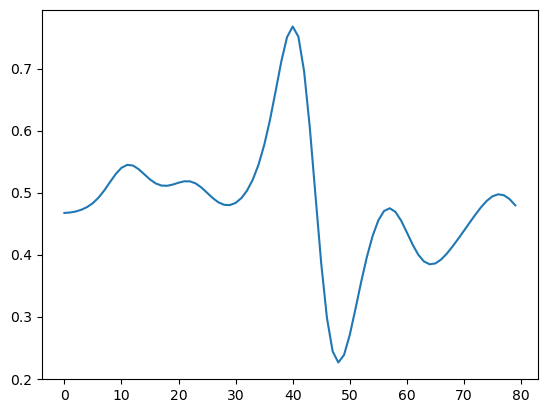

In [237]:
plt.plot(im_blur_gradient[:,500,492])

In [238]:
from imageUtils import find_z_of_maximal_gradient
from measurements import fix_holes_in_height_image, make_image_from_heightmap, \
    find_subgraphs_of_connected_local_maxima

# Iz = find_z_of_maximal_gradient(im_blur_gradient,method='maximum',threshold=0.17)
# Iz = np.argmax(im_blur > 0.18, axis=0)
# height_image = make_image_from_heightmap(Iz,im.shape[0])

S,G = find_subgraphs_of_connected_local_maxima(im_blur,return_full_graph=True)


100%|████████████████████████████████████████████| 512/512 [00:24<00:00, 21.07it/s]


In [239]:
distances = np.array([np.mean( np.abs(np.array(list(s.nodes))[:,2] - 40))  for s in S])
distances.argsort()

array([ 1,  0, 18,  3, 23, 24, 26, 27,  9, 10,  8, 12, 20, 22,  4, 21,  5,
        6, 25,  2, 17,  7, 16, 15, 14, 11, 19, 13])

In [240]:
np.array(S[1].nodes).shape

(261967, 3)

/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:172: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


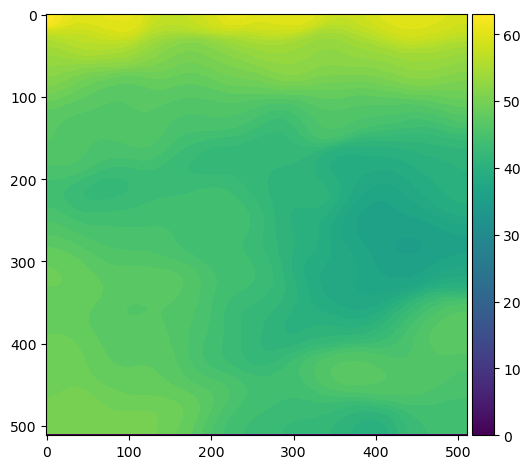

In [241]:
from measurements import reconstruct_surface_from_subgraph,reconstruct_bm_from_subgraph
# Iz_fixed,height_image_fixed = fix_holes_in_height_image(height_image,im.shape)
# S.sort(key=lambda g: len({(x, y) for x, y, z in g.nodes}), reverse=True)

Iz_fixed,height_image_fixed = reconstruct_bm_from_subgraph(S[1],im_blur)

plt.figure()
io.imshow(Iz_fixed)

In [242]:
stackview.switch({'a6':im,'heightmap':height_image_fixed},
                colormap=['pure_red','pure_green'],
                toggleable=True,zoom_factor=0.5)

In [243]:
# Save

io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_heightmap.tif'),
          Iz_fixed.astype(np.int8))

io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_height_image.tif'),
          height_image_fixed.astype(np.int8))
io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_blur_diff.tif'),
          util.img_as_uint(im_blur_gradient))
io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_blur.tif'),
          util.img_as_uint(im_blur))


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/07-13-2026 whole hindpaw a6 K10 long incubation/Cage 5995 1.5 month female/3dperm_7dprim_7dsecond/3-3/3-3_height_image.tif is a low contrast image
  return func(*args, **kwargs)


# Surface curvature

In [3]:
from measurements import get_mesh_from_bm_image
idx = 2

height_image_fixed = io.imread(path.join(manifest.loc[idx]['Dirname'],
                               str(manifest.loc[idx]['FOV']) + '_height_image.tif'))

dx = 0.2071607
surf = get_mesh_from_bm_image(height_image_fixed, spacing=[dz,dx,dx], decimation_factor=100)

pl = pv.Plotter()
pl.add_mesh(pv.wrap(surf))
pl.show()

Widget(value='<iframe src="http://localhost:50586/index.html?ui=P_0x176ddf2f0_0&reconnect=auto" class="pyvista…

In [6]:
from measurements import get_tissue_curvature_over_grid, get_tissue_curvature_sparse

mean_curvature, gaussian_curvature = get_tissue_curvature_sparse(surf, kappa=10)
np.savez(path.join(manifest.loc[idx]['Dirname'],
                               str(manifest.loc[idx]['FOV']) + '_mesh.npz'),
                   vertices=surf.vertices,faces=surf.faces,values=mean_curvature)


mean_curvature, gaussian_curvature = get_tissue_curvature_over_grid(surf, height_image_fixed.shape,
                                                                    kappa=10, spacing=[dz,dx,dx])
io.imsave(path.join(manifest.loc[idx]['Dirname'],'mean_curvature.tif'), mean_curvature.T)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x103992bd0>>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 



# Projecting the a6 intensity along surface

In [8]:
from imageUtils import reslice_by_heightmap
from scipy.ndimage import gaussian_filter

idx = 2
print(manifest.loc[idx]['FOV'])

# Reload curvature + mask
im = gaussian_filter(io.imread(path.join(manifest.loc[idx]['Filename'])).astype(float)[...,channel],[2,5,5])
mean_curvature = io.imread(path.join(manifest.loc[idx]['Dirname'],'mean_curvature.tif'))

height_image = io.imread(path.join(manifest.loc[idx]['Dirname'],
                               str(manifest.loc[idx]['FOV'])+'_height_image.tif'))
Iz_fixed = np.argmax(height_image,axis=0)

border_size = 20

bm_a6_intensity = reslice_by_heightmap(im,Iz_fixed,
                                        top_border=-border_size,bottom_border=border_size)
stackview.slice(bm_a6_intensity)
io.imsave(path.join(manifest.loc[idx]['Dirname'],'flat.tif'),bm_a6_intensity)

1-4


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


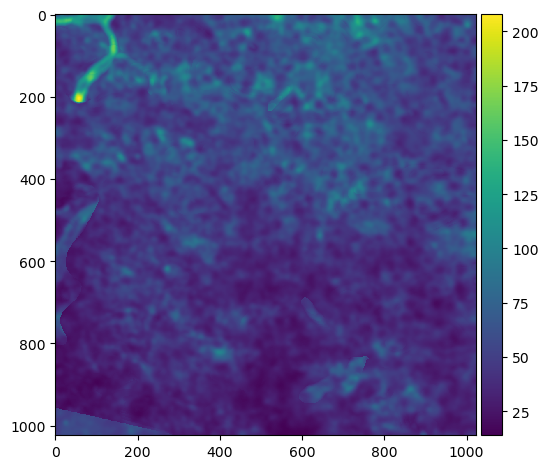

In [9]:
mask = io.imread(path.join(manifest.loc[idx]['Dirname'],
                           str(manifest.loc[idx]['FOV']) +'_mask.tif')).astype(bool)
bm_MIP = bm_a6_intensity[13:22,...].max(axis=0)
mean_curvature_masked = mean_curvature.copy()
mean_curvature_masked[~mask] = np.nan

bm_MIP_smooth_masked = bm_MIP.copy().astype(float)
bm_MIP_smooth_masked[~mask] = np.nan

io.imshow(bm_MIP)
io.imsave( path.join(manifest.loc[idx]['Dirname'],'bm_a6_intensity.tif'), bm_MIP_smooth_masked)

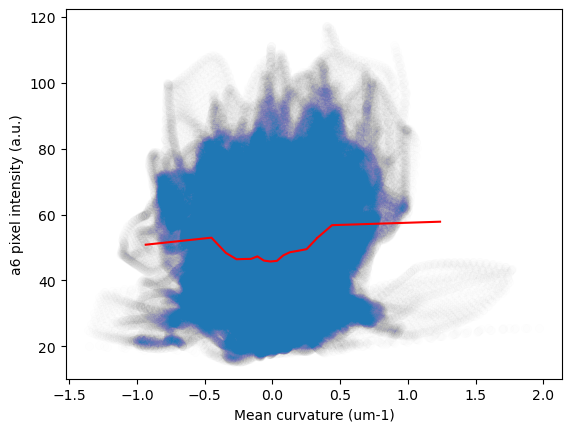

<Figure size 640x480 with 0 Axes>

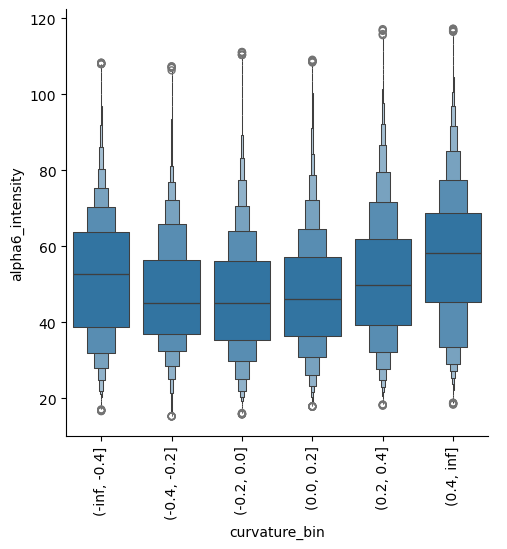

In [11]:
from basicUtils import plot_bin_means

plt.scatter(mean_curvature_masked.flatten(),bm_MIP_smooth_masked.flatten(), alpha=0.005)
plot_bin_means(mean_curvature_masked.flatten(),bm_MIP_smooth_masked.flatten(),bin_edges=18,color='r',
               bin_style='percentile',mean='mean')
plt.xlabel('Mean curvature (um-1)'),
plt.ylabel('a6 pixel intensity (a.u.)')
# plt.hlines(np.nanmean(bm_MIP_smooth.flatten()),xmin= -0.4,xmax=0.5)

plt.figure()
df = pd.DataFrame.from_dict({'curvature':mean_curvature_masked.flatten(),
                             'alpha6_intensity':bm_MIP_smooth_masked.flatten()}).dropna()
df['curvature_bin'],bins = pd.cut(df['curvature'],bins=[-np.inf,-.4,-.2,0,.2,.4,np.inf],retbins=True)
sb.catplot(df,x='curvature_bin',y='alpha6_intensity',kind='boxen')

plt.xticks(rotation=90)

df.to_csv(path.join(manifest.loc[idx]['Dirname'],'a6_intensity.csv'))

In [255]:
from scipy import stats
stats.pearsonr(df['curvature'],df['alpha6_intensity'])

PearsonRResult(statistic=np.float64(0.2725277336851824), pvalue=np.float64(0.0))

# Load and plot in batch

In [256]:
dirnames['M1'].rglob('a6_intensity.csv')

<generator object Path.rglob at 0x3747afcd0>

In [43]:
from pathlib import Path

dirnames = {'M1':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/05-24-2026 ASAP uninduced antibody tests/DAPI alpha6488/'),
           'M2':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/07-13-2026 whole hindpaw a6 K10 long incubation/Cage 5995 1.5 month female/3dperm_7dprim_7dsecond/Female 1/'),
           'M3':Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/07-13-2026 whole hindpaw a6 K10 long incubation/Cage 5995 1.5 month female/3dperm_7dprim_7dsecond/Female 2/')}

mice = []; flist = []
for mouse,d in dirnames.items():
    this_regions = list(d.rglob('a6_intensity.csv'))
    for file in this_regions:
        mice.append(mouse)
        flist.append(file)

df = []
for i,f in enumerate(flist):
    _df = pd.read_csv(f,index_col=0)
    _df['Region'] = i
    _df['Mean a6'] = _df['alpha6_intensity'].mean()
    _df['Mouse'] = mice[i]
    df.append(_df)

df = pd.concat(df,ignore_index=True)
df['curvature_bin'],bins = pd.cut(df['curvature'],bins=[-np.inf,-.6,-.4,-.2,0,.2,.4,.6,np.inf],retbins=True)
df['Concavity'] = df['curvature'] > 0
df.loc[(df['curvature'] < 0.2) & (df['curvature'] > -0.2),'Concavity bin'] = 'Flat'
df.loc[df['curvature'] > 0.2,'Concavity bin'] = 'Concave'
df.loc[df['curvature'] < -0.2,'Concavity bin'] = 'Convex'

df['a6_norm'] = df['alpha6_intensity'] / df['Mean a6']

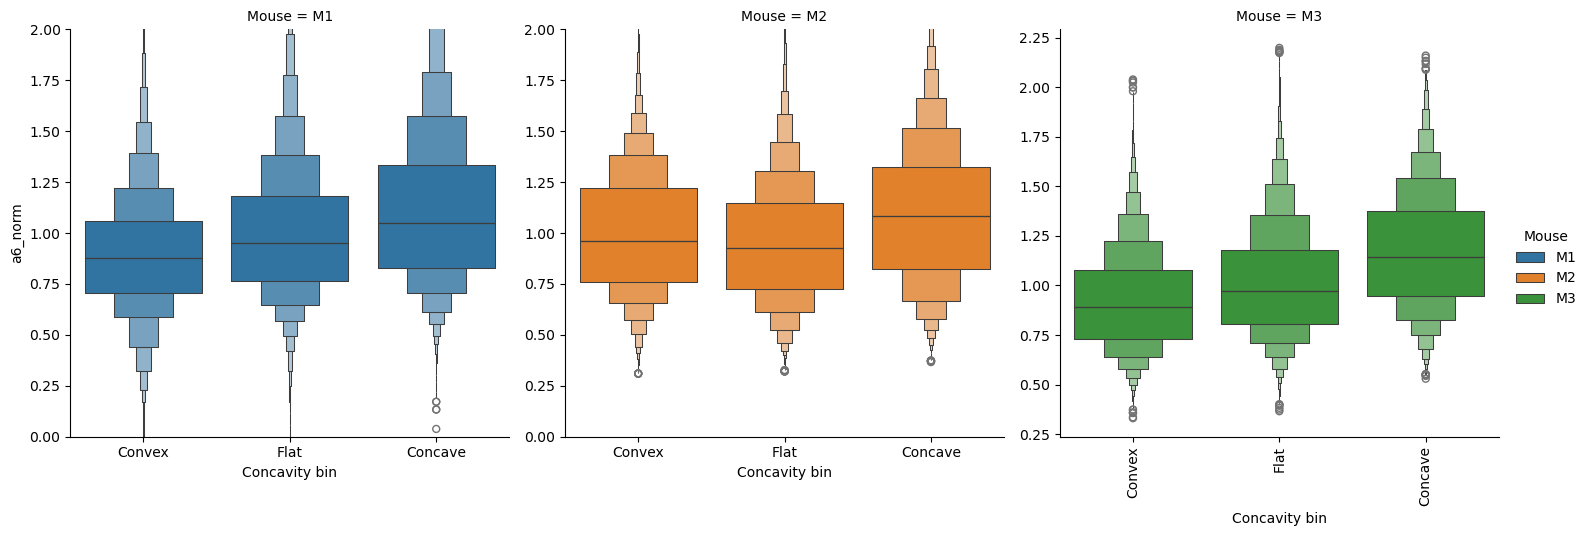

In [44]:
g = sb.catplot(df,x='Concavity bin',y='a6_norm',col='Mouse',hue='Mouse',kind='boxen',
          order=['Convex','Flat','Concave'],sharey=False)
plt.xticks(rotation=90)
g.axes[0,0].set_ylim([0,2])
g.axes[0,1].set_ylim([0,2])

plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/curvature_binned.svg')

In [55]:
from scipy import stats

stats.ttest_ind(
df.set_index('Mouse').loc['M1'].set_index('Concavity bin').loc['Convex']['a6_norm'],
df.set_index('Mouse').loc['M1'].set_index('Concavity bin').loc['Concave']['a6_norm'])

TtestResult(statistic=np.float64(-97.62210318747474), pvalue=np.float64(0.0), df=np.float64(100504.0))

(np.float64(-64.54966307495228), np.float64(0.0))
(np.float64(6.559539556082014), np.float64(5.415094708251796e-11))
(np.float64(-34.81965732113505), np.float64(1.7190135877278524e-264))
(np.float64(-61.86579034826226), np.float64(0.0))
(np.float64(-105.07673321641583), np.float64(0.0))
(np.float64(-56.303140292073664), np.float64(0.0))
(np.float64(26.4424040210546), np.float64(5.479959688279091e-154))
(np.float64(0.40808278622439553), np.float64(0.6832135433165845))
(np.float64(7.901584174510323), np.float64(2.7725784027241293e-15))
(np.float64(-62.89945605534904), np.float64(0.0))


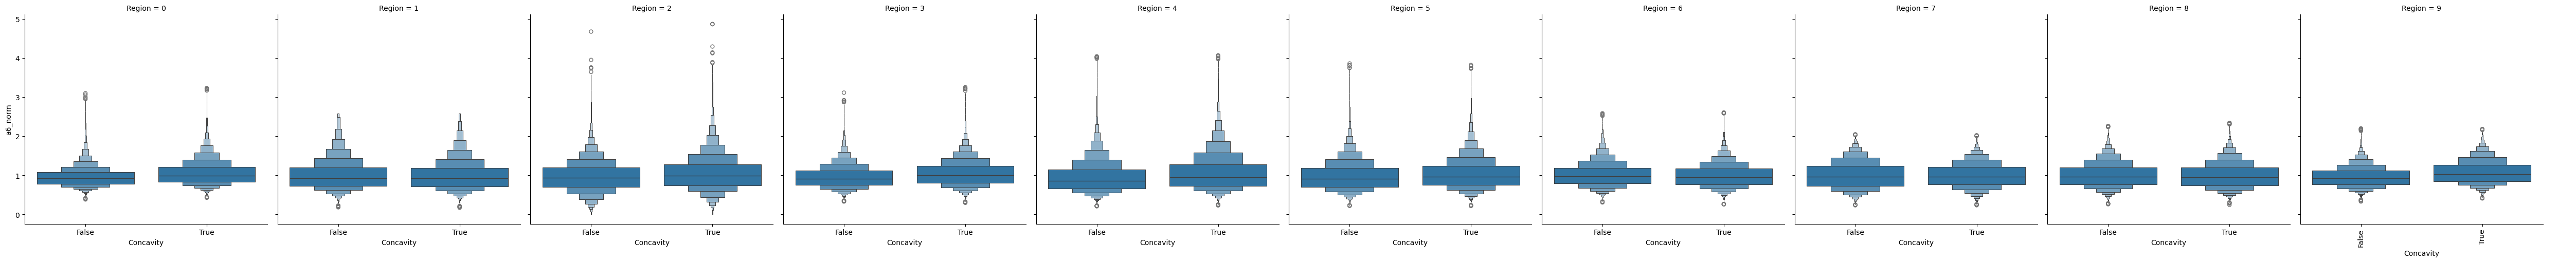

In [263]:
from basicUtils import ttest_from_groupby

sb.catplot(df,x='Concavity',y='a6_norm',col='Region',kind='boxen')
plt.xticks(rotation=90)
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/curvature_binned_regions.svg')

for region,_df in df.groupby('Region'):
    print(ttest_from_groupby(_df,field2group='Concavity',field2test='a6_norm'))
    

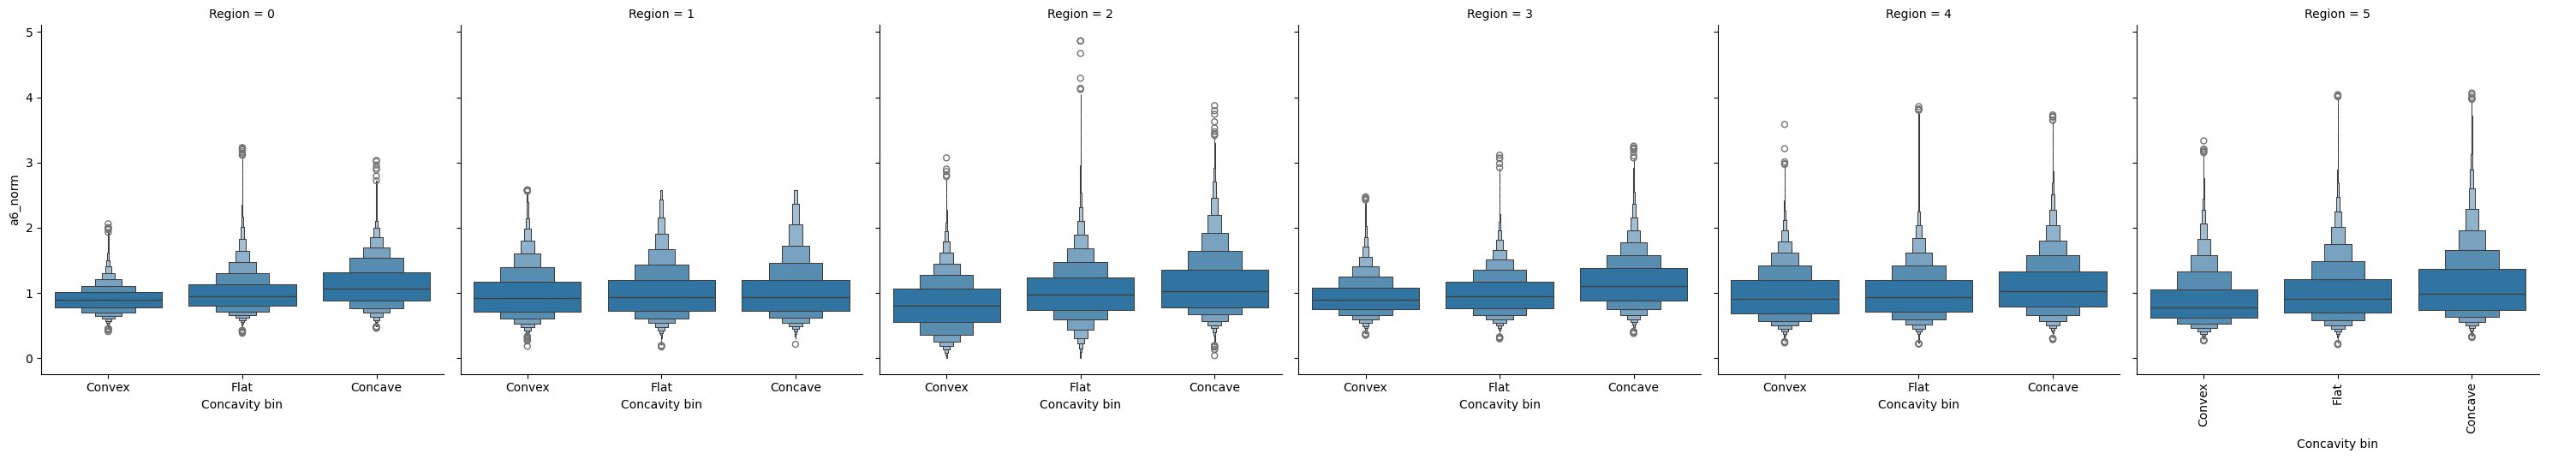

In [67]:
sb.catplot(df,x='Concavity bin',y='a6_norm',col='Region',kind='boxen',
           order=['Convex','Flat','Concave'])
plt.xticks(rotation=90)
plt.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/Integrin stains/curvature_binned_regions.svg')
